
--- Outcome Summary up to Episode 200 ---
successful landing       : 16
failed landing           : 154
crash before runway      : 30
stall midair             : 0
timeout                  : 0
Runway success probabilities: {0.0: 0.12121212121212122, 0.5: 0.08823529411764706, 1.0: 0.030303030303030304}
------------------------------------------


--- Outcome Summary up to Episode 400 ---
successful landing       : 22
failed landing           : 309
crash before runway      : 66
stall midair             : 3
timeout                  : 0
Runway success probabilities: {0.0: 0.09090909090909091, 0.5: 0.061224489795918366, 1.0: 0.015151515151515152}
------------------------------------------


--- Outcome Summary up to Episode 600 ---
successful landing       : 23
failed landing           : 487
crash before runway      : 78
stall midair             : 12
timeout                  : 0
Runway success probabilities: {0.0: 0.05851063829787234, 0.5: 0.04524886877828054, 1.0: 0.010471204188481676}
----

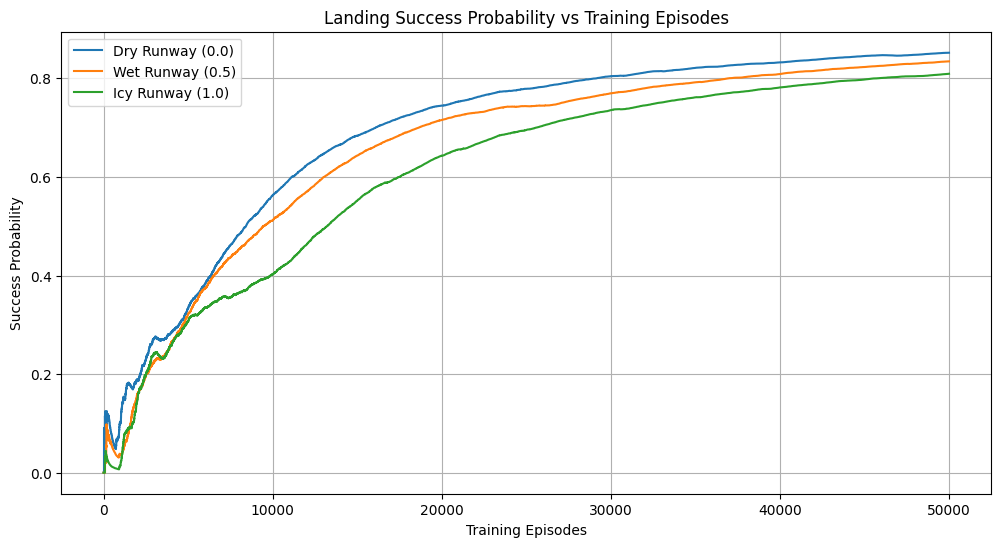

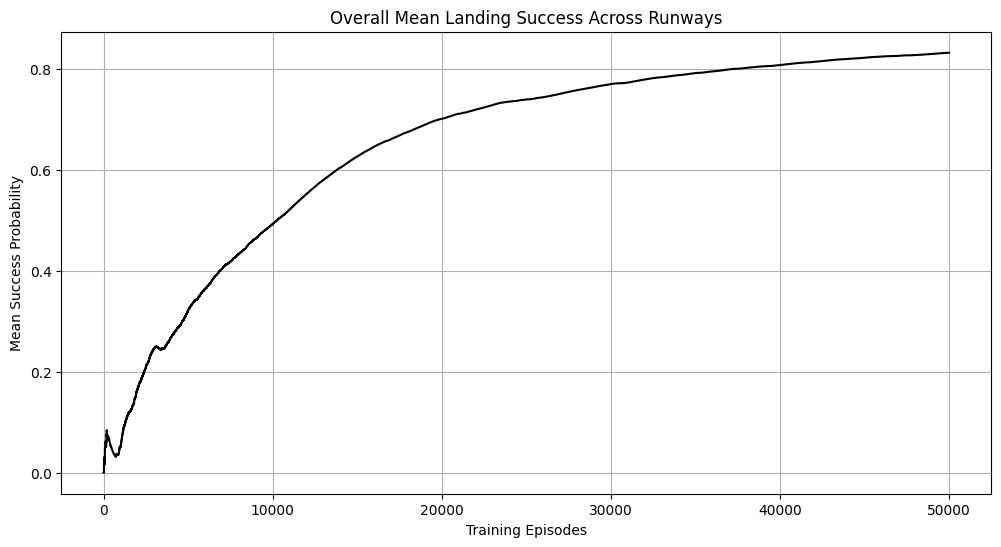


Training complete.
Final outcomes: {'successful landing': 41598, 'failed landing': 7689, 'crash before runway': 651, 'stall midair': 62, 'timeout': 0}


In [1]:
# train_dqn_full.py
"""
Enhanced DQN training script for Flight Landing.
- Simulates 3 runway types: Dry, Wet, Icy (different drag physics)
- Softer penalties, stronger landing reward
- Prints outcome summary every 200 episodes
- NOW plots training graphs at the end
"""

import argparse
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt

# =====================================================
# 1️⃣ ENVIRONMENT
# =====================================================
class FlightEnv(gym.Env):
    """Simplified Flight Landing Environment with runway condition physics."""
    def __init__(self, start_alt=400.0, start_dist=800.0):
        super().__init__()
        self.observation_space = spaces.Box(
            low=np.array([0, 0, 0, -30, 0], dtype=np.float32),
            high=np.array([5000, 300, 10000, 30, 1], dtype=np.float32),
            dtype=np.float32
        )
        self.action_space = spaces.Discrete(5)
        self.start_alt = start_alt
        self.start_dist = start_dist
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.altitude = float(self.start_alt)
        self.speed = float(160 + np.random.uniform(-10, 10))
        self.distance = float(self.start_dist)
        self.prev_distance = self.distance
        self.angle = float(np.random.uniform(-2, 2))

        # Three runway conditions
        self.runway_condition = float(np.random.choice([0.0, 0.5, 1.0]))
        self.steps = 0
        return self._get_obs(), {}

    def step(self, action):
        self.steps += 1

        # Action effects
        if action == 0: self.speed += 6
        elif action == 1: self.speed -= 6
        elif action == 2: self.altitude += 35; self.angle += 1.5
        elif action == 3: self.altitude -= 35; self.angle -= 1.5

        # Physics
        self.distance -= max(self.speed * 0.3, 1)
        self.altitude -= 8

        # Runway friction physics
        drag = {0.0: 0.6, 0.5: 0.4, 1.0: 0.25}[self.runway_condition]
        self.speed -= drag

        self.angle = np.clip(self.angle, -30, 30)
        self.altitude = max(self.altitude, 0)
        self.speed = np.clip(self.speed, 0, 300)

        # Reward shaping
        reward = 0
        reward += (self.prev_distance - self.distance) * 0.02
        self.prev_distance = self.distance
        reward -= 0.03
        reward -= 0.005 * abs(self.altitude - 100)
        reward -= 0.005 * abs(self.speed - 150)
        reward -= 0.01 * abs(self.angle)
        if self.distance < 400: reward += 0.8
        if 0 < self.altitude < 100 and 100 < self.speed < 200: reward += 1.5
        reward += (self.start_dist - self.distance) / self.start_dist

        done, success = False, False
        outcome = "in-flight"

        # Terminal conditions
        if self.distance <= 0:
            if 0 <= self.altitude <= 50 and 100 <= self.speed <= 200 and abs(self.angle) < 10:
                reward += 200
                success = True
                outcome = "successful landing"
            else:
                reward -= 40
                outcome = "failed landing"
            done = True

        elif self.altitude <= 0:
            reward -= 40
            done = True
            outcome = "crash before runway"

        elif self.speed <= 20 and self.altitude > 100:
            reward -= 40
            done = True
            outcome = "stall midair"

        elif self.steps >= 600:
            done = True
            outcome = "timeout"

        return self._get_obs(), reward, done, False, {
            "success": success,
            "outcome": outcome,
            "runway": self.runway_condition
        }

    def _get_obs(self):
        return np.array([
            self.altitude / 5000,
            self.speed / 300,
            self.distance / 10000,
            (self.angle + 30) / 60,
            self.runway_condition
        ], dtype=np.float32)


# =====================================================
# 2️⃣ REPLAY BUFFER
# =====================================================
class ReplayBuffer:
    def __init__(self, capacity, shape):
        self.capacity = capacity
        self.ptr = 0
        self.size = 0
        self.states = np.zeros((capacity,) + shape, np.float32)
        self.next_states = np.zeros((capacity,) + shape, np.float32)
        self.actions = np.zeros(capacity, np.int64)
        self.rewards = np.zeros(capacity, np.float32)
        self.dones = np.zeros(capacity, np.float32)

    def push(self, s, a, r, ns, d):
        self.states[self.ptr] = s
        self.next_states[self.ptr] = ns
        self.actions[self.ptr] = a
        self.rewards[self.ptr] = r
        self.dones[self.ptr] = d
        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch):
        idx = np.random.randint(0, self.size, batch)
        return dict(
            states=self.states[idx],
            next_states=self.next_states[idx],
            actions=self.actions[idx],
            rewards=self.rewards[idx],
            dones=self.dones[idx],
        )

    def __len__(self): return self.size


# =====================================================
# 3️⃣ NETWORK + AGENT
# =====================================================
class QNetwork(nn.Module):
    def __init__(self, obs_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, n_actions)
        )

    def forward(self, x): return self.net(x)


class DQNAgent:
    def __init__(self, obs_dim, n_actions, lr, gamma, device):
        self.device = torch.device(device)
        self.q = QNetwork(obs_dim, n_actions).to(self.device)
        self.tq = QNetwork(obs_dim, n_actions).to(self.device)
        self.tq.load_state_dict(self.q.state_dict())
        self.opt = optim.Adam(self.q.parameters(), lr=lr)
        self.gamma = gamma
        self.loss_fn = nn.MSELoss()

    def act(self, obs, eps):
        if np.random.rand() < eps:
            return np.random.randint(self.q.net[-1].out_features)
        with torch.no_grad():
            t = torch.tensor(obs, dtype=torch.float32, device=self.device).unsqueeze(0)
            return int(self.q(t).argmax().item())

    def update(self, batch):
        s = torch.tensor(batch["states"], dtype=torch.float32, device=self.device)
        ns = torch.tensor(batch["next_states"], dtype=torch.float32, device=self.device)
        a = torch.tensor(batch["actions"], dtype=torch.int64, device=self.device)
        r = torch.tensor(batch["rewards"], dtype=torch.float32, device=self.device)
        d = torch.tensor(batch["dones"], dtype=torch.float32, device=self.device)

        q = self.q(s).gather(1, a.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            tgt = r + (1 - d) * self.gamma * self.tq(ns).max(1)[0]

        loss = self.loss_fn(q, tgt)
        self.opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.q.parameters(), 10)
        self.opt.step()

    def sync(self): self.tq.load_state_dict(self.q.state_dict())


# =====================================================
# 4️⃣ TRAINING
# =====================================================
def parse_args():
    p = argparse.ArgumentParser()
    p.add_argument("--episodes", type=int, default=50000)
    p.add_argument("--lr", type=float, default=3e-4)
    p.add_argument("--buffer_size", type=int, default=30000)
    p.add_argument("--batch_size", type=int, default=128)
    p.add_argument("--eps_start", type=float, default=1.0)
    p.add_argument("--eps_end", type=float, default=0.05)
    p.add_argument("--eps_decay", type=float, default=0.995)
    p.add_argument("--target_update", type=int, default=1000)
    p.add_argument("--save_dir", type=str, default="./checkpoints")
    p.add_argument("--cpu", action="store_true")
    return p.parse_args()


def train(args):
    device = "cuda" if torch.cuda.is_available() and not args.cpu else "cpu"

    env = FlightEnv()
    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    agent = DQNAgent(obs_dim, n_actions, lr=args.lr, gamma=0.99, device=device)
    buffer = ReplayBuffer(args.buffer_size, (obs_dim,))
    epsilon = args.eps_start

    os.makedirs(args.save_dir, exist_ok=True)

    # Outcome tracking
    outcomes = {k: 0 for k in ["successful landing", "failed landing", "crash before runway", "stall midair", "timeout"]}
    runway_counts = {0.0: 0, 0.5: 0, 1.0: 0}
    runway_success = {0.0: 0, 0.5: 0, 1.0: 0}

    # For plotting
    success_curve = {0.0: [], 0.5: [], 1.0: []}
    mean_curve = []

    best_return = -1e9
    total_steps = 0

    for ep in range(1, args.episodes + 1):
        obs, _ = env.reset()
        done = False
        ep_ret = 0
        runway = env.runway_condition

        while not done:
            act = agent.act(obs, epsilon)
            nobs, r, done, _, info = env.step(act)
            buffer.push(obs, act, r, nobs, done)
            obs = nobs
            ep_ret += r
            total_steps += 1

            if len(buffer) > args.batch_size:
                agent.update(buffer.sample(args.batch_size))

            if total_steps % args.target_update == 0:
                agent.sync()

        epsilon = max(args.eps_end, epsilon * args.eps_decay)

        # Track outcomes
        outcome = info["outcome"]
        outcomes[outcome] += 1
        runway_counts[runway] += 1
        if info["success"]:
            runway_success[runway] += 1

        # Track success curves
        for rwy in [0.0, 0.5, 1.0]:
            if runway_counts[rwy] > 0:
                success_curve[rwy].append(runway_success[rwy] / runway_counts[rwy])
            else:
                success_curve[rwy].append(0.0)

        mean_curve.append(
            np.mean([
                success_curve[0.0][-1],
                success_curve[0.5][-1],
                success_curve[1.0][-1],
            ])
        )

        # Print summary every 200 episodes
        if ep % 200 == 0:
            runway_probs = {
                k: runway_success[k] / runway_counts[k] if runway_counts[k] > 0 else 0
                for k in runway_counts
            }
            print(f"\n--- Outcome Summary up to Episode {ep} ---")
            for k, v in outcomes.items(): print(f"{k:<25}: {v}")
            print("Runway success probabilities:", runway_probs)
            print("------------------------------------------\n")

        # Save best
        if ep_ret > best_return:
            best_return = ep_ret
            torch.save(agent.q.state_dict(), os.path.join(args.save_dir, "best_model.pt"))

    # =================================================
    # PLOTTING SECTION (added)
    # =================================================

    episodes = np.arange(1, args.episodes + 1)

    # Plot 1: Per-runway success probability
    plt.figure(figsize=(12,6))
    plt.plot(episodes, success_curve[0.0], label="Dry Runway (0.0)")
    plt.plot(episodes, success_curve[0.5], label="Wet Runway (0.5)")
    plt.plot(episodes, success_curve[1.0], label="Icy Runway (1.0)")
    plt.title("Landing Success Probability vs Training Episodes")
    plt.xlabel("Training Episodes")
    plt.ylabel("Success Probability")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Plot 2: Mean landing success
    plt.figure(figsize=(12,6))
    plt.plot(episodes, mean_curve, color="black")
    plt.title("Overall Mean Landing Success Across Runways")
    plt.xlabel("Training Episodes")
    plt.ylabel("Mean Success Probability")
    plt.grid(True)
    plt.show()

    print("\nTraining complete.")
    print("Final outcomes:", outcomes)


# =====================================================
# 5️⃣ RUN
# =====================================================
if __name__ == "__main__":
    import sys
    sys.argv = [sys.argv[0]]  # Fix notebook arguments
    args = parse_args()
    train(args)
